# Chromosome IV Replicate 1 - Prototype Replication Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs


In [3]:
config, _ = load_default_chrom_configs()
config.shift_parameters_for_alpha()

real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1, chr=4)

Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0


In [4]:
real_deconv1.update_parameters({'mu0': 14.9,
 'delta': 15.1,
 'sigma0': 6.3,
 'sigmav': 0.029,
 'lambda': 59.0,
 'gamma1': 0.663,
 'gamma2': 1.0,
 'halted': 0,
 'alpha': 22})


In [5]:
from src.optimize_H import ParameterOptimizer, create_bounds_params_from_config, run_epochs

In [6]:
params_df = create_bounds_params_from_config(config)

In [7]:
real_deconv1.setup_deconvolution(real_deconv1.config)

Initializing N using config H.
Initializing B using timepoint 0


In [8]:
real_deconv1.iterative_deconvolution_updates(20, verbose=False)

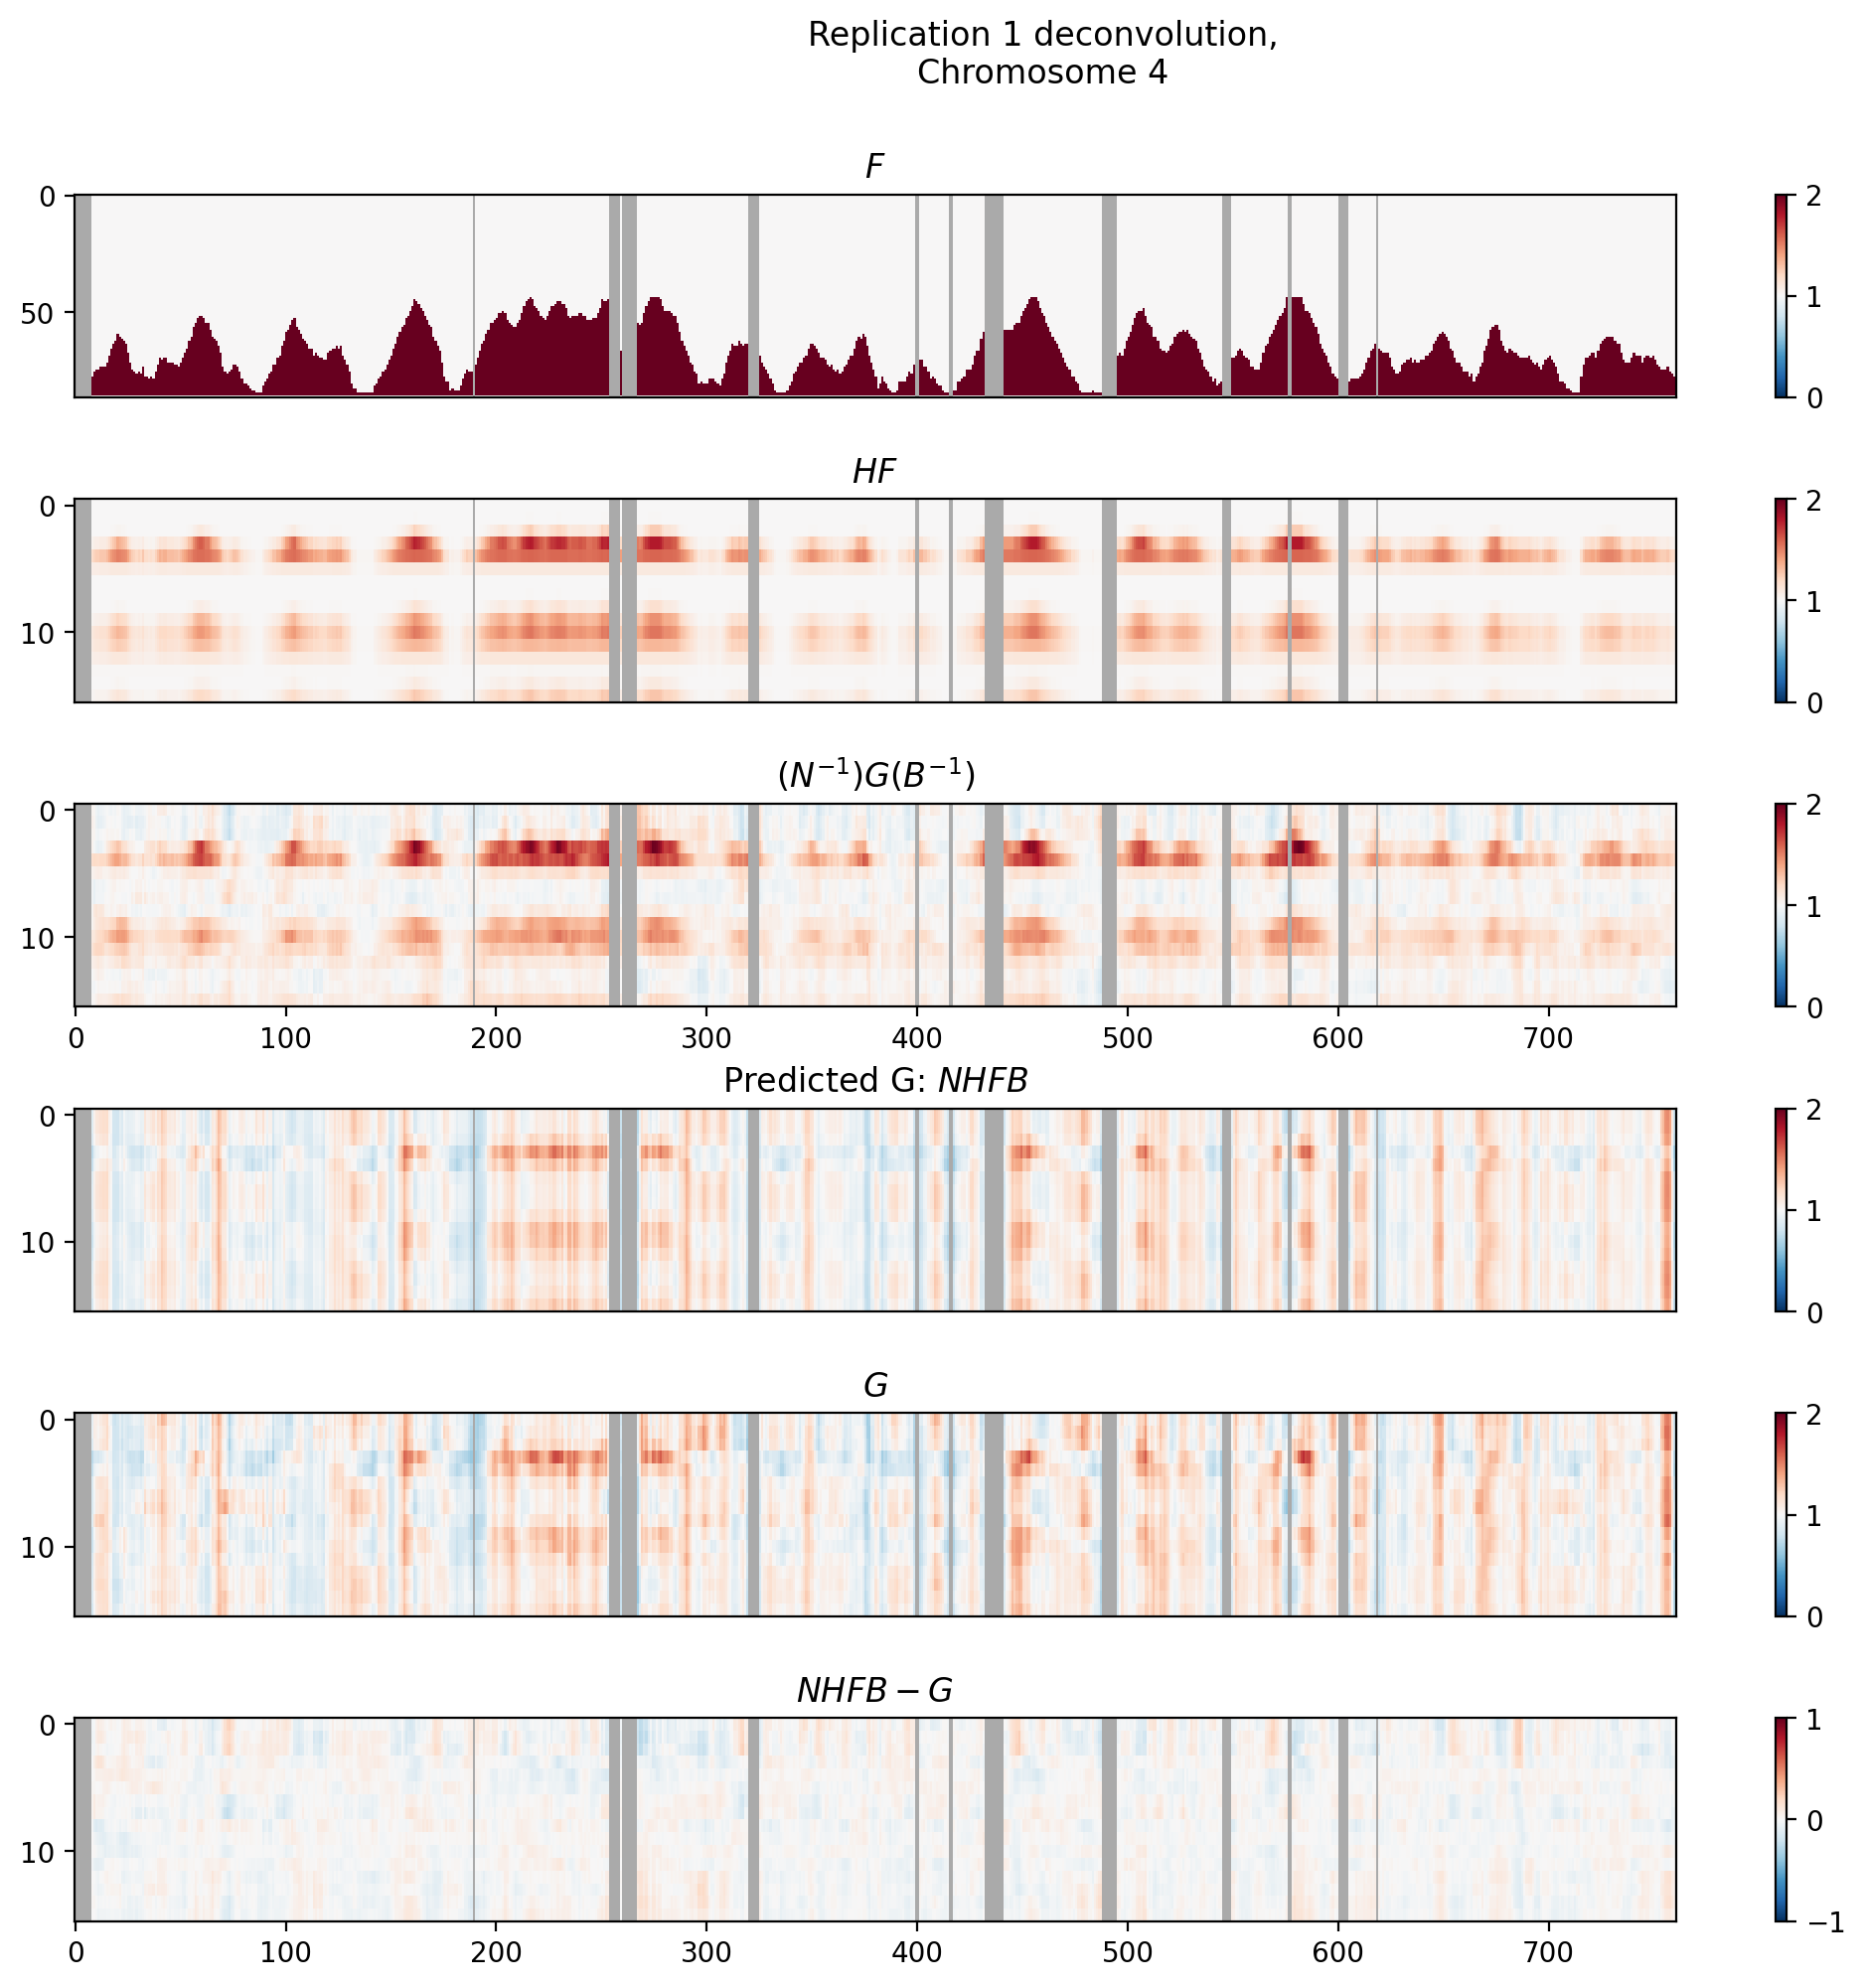

In [9]:
real_deconv1.plot_heatmaps()

In [ ]:
update_params_df, Hs, Fs, Ns, Bs = run_epochs(real_deconv1, params_df, 100)

Epoch:  0
Optimization [1]: Current loss: 0.002850260243556183
Optimization [101]: Current loss: 0.0028406339000111684
Optimization [201]: Current loss: 0.00283660472915505
Optimization [301]: Current loss: 0.0028354530577776316
Optimization terminated successfully.
         Current function value: 0.002835
         Iterations: 220
         Function evaluations: 349
00:01:49.298
mu0           15.384788
lambda        59.555696
delta         14.663623
sigma0         6.117280
sigmav         0.041968
gamma1         0.664627
gamma2         1.000000
halted         0.000019
opt_H_loss     0.002835
F_rn           0.002827
Name: 0, dtype: float64
Epoch:  1
Optimization [1]: Current loss: 0.0028265392544861673
Optimization [101]: Current loss: 0.002821318239544667
Optimization [201]: Current loss: 0.0028207237257763455
Optimization terminated successfully.
         Current function value: 0.002821
         Iterations: 165
         Function evaluations: 265
00:03:20.286
mu0           15.618534
la

Optimization [1]: Current loss: 0.0027983492984761152
Optimization [101]: Current loss: 0.002798285655919609
Optimization terminated successfully.
         Current function value: 0.002798
         Iterations: 68
         Function evaluations: 126
00:21:46.433
mu0           15.298734
lambda        60.192074
delta         15.094990
sigma0         6.062535
sigmav         0.054035
gamma1         0.653532
gamma2         1.000000
halted         0.000019
opt_H_loss     0.002798
F_rn           0.002798
Name: 15, dtype: float64
Epoch:  16
Optimization [1]: Current loss: 0.002798142557056012
Optimization [101]: Current loss: 0.0027980997089619057
Optimization terminated successfully.
         Current function value: 0.002798
         Iterations: 75
         Function evaluations: 138
00:23:01.217
mu0           15.271508
lambda        60.185250
delta         15.112152
sigma0         6.066836
sigmav         0.054146
gamma1         0.652976
gamma2         1.000000
halted         0.000019
opt_H_loss

00:38:13.356
mu0           15.054246
lambda        60.130512
delta         15.210417
sigma0         6.106398
sigmav         0.054808
gamma1         0.648520
gamma2         1.000000
halted         0.000020
opt_H_loss     0.002797
F_rn           0.002796
Name: 30, dtype: float64
Epoch:  31
Optimization [1]: Current loss: 0.0027964512222380584
Optimization [101]: Current loss: 0.0027964470962873857
Optimization terminated successfully.
         Current function value: 0.002796
         Iterations: 57
         Function evaluations: 110
00:39:17.392
mu0           15.039276
lambda        60.125008
delta         15.217215
sigma0         6.106639
sigmav         0.054818
gamma1         0.648282
gamma2         1.000000
halted         0.000020
opt_H_loss     0.002796
F_rn           0.002796
Name: 31, dtype: float64
Epoch:  32
Optimization [1]: Current loss: 0.002796355404751226
Optimization [101]: Current loss: 0.0027963615797219265
Optimization terminated successfully.
         Current function 

In [ ]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

In [ ]:
plt.imshow(real_deconv1.H, vmax=0.05)

In [ ]:
real_deconv1.plot_heatmaps()

In [ ]:
fig = plt.figure(figsize=(4, 3))
plt.imshow(config.H, vmax=0.1, aspect='auto', interpolation='none')

In [ ]:
config.params_dic

In [ ]:
from src.chromatin_model import draw_phase_label_annotations
config = real_deconv1.config

fig = plt.figure(figsize=(4, 3))
t_indices = config.get_Hpositions_for_branch('t')
t_tps = config.get_timepoints_for_branch('t')
plt.plot(t_tps, real_deconv1.F.mean(axis=1)[t_indices])
draw_phase_label_annotations(plt.gca(), config, flip=True, annotations_x=0.85)
plt.xlim(t_tps[0], t_tps[-1])
plt.ylim(0.8, 2.1)
plt.suptitle("Average single cell copy number, replicate 1, chrIV")

# Plot when 95% of the genome has been replicated
x, y = t_tps, real_deconv1.F.mean(axis=1)[t_indices]
g2m_start = t_tps[y > 1.95][0]
plt.axvline(g2m_start)
config.params_dic['lambda'] - g2m_start